# Exploration

Imports

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from statsmodels.graphics.tsaplots import plot_acf
from pandas.api.types import CategoricalDtype
import nbformat

import json

## Milestone 1

In [12]:
GROUP_ID_TO_NAME = {
    "1": "Metabolic Syndrome",
    "2a": "Obese, no Bariatric, no Diabetes, no CAD",
    "2b": "Obese, with Bariatric, no Diabetes, no CAD",
    "3": "T2D, no CAD",
    "4": "Acute CAD",
    "5": "Chronic CAD, no Heart Failure",
    "6": "Chronic CAD, Heart Failure",
    "7": "Chronic congestive Heart Failure, no CAD",
    "8": "Control"
}

### Part 1 - Metadata exploration

In [13]:
metadata_df = pd.read_csv("train/metadata.csv")
metagenomics_df = pd.read_csv("train/microbiome.csv")

#### Distribution of disease in metadata

In [14]:
metadata_df.head(10)

,SampleID,PATGROUPFINAL_C,GENDER,AGE,CENTER_C,SMOKE,pa_work_2cl,DDS
0,x30MCx2308,5,NaN,NaN,Danemark,NaN,NaN,NaN
1,x30MCx3215,5,NaN,NaN,Danemark,NaN,NaN,NaN
2,x30MCx2753,5,NaN,NaN,Danemark,NaN,NaN,NaN
3,x12MCx2285,5,1.0,56.0,France,0.0,0.0,22.0
4,x30MCx1686,5,NaN,NaN,Danemark,NaN,NaN,NaN
5,x12MCx2576,5,1.0,68.0,France,0.0,1.0,25.0
6,x30MCx2656,5,NaN,NaN,Danemark,NaN,NaN,NaN
7,x12MCx2446,5,1.0,60.0,France,0.0,1.0,16.0
8,x30MCx2303,5,NaN,NaN,Danemark,NaN,NaN,NaN
9,x30MCx1761,5,NaN,NaN,Danemark,NaN,NaN,NaN


In [15]:
value_col = "PATGROUPFINAL_C"

In [16]:
print(f"Number of controls: {metadata_df[metadata_df[value_col] == '8']['SampleID'].count()}")
print(f"Number of cases: {metadata_df[metadata_df[value_col] != '8']['SampleID'].count()}")
print(f"Total samples: {metadata_df['SampleID'].count()}")

Number of controls: 170
Number of cases: 1213
Total samples: 1383


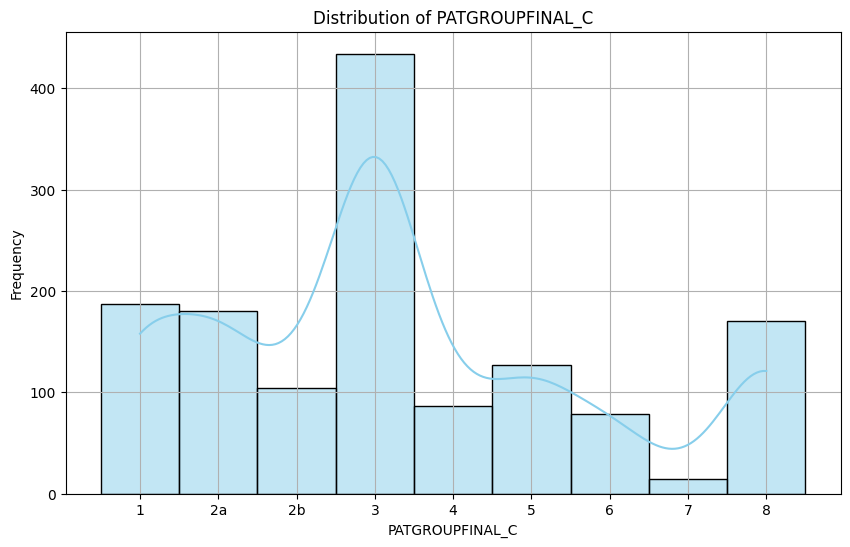

In [17]:
metadata_sorted_disease_group_df = metadata_df.sort_values(by=value_col)
plt.figure(figsize=(10, 6))
sns.histplot(metadata_sorted_disease_group_df[value_col], kde=True, bins=30, color='skyblue')
plt.title(f'Distribution of PATGROUPFINAL_C')
plt.xlabel("PATGROUPFINAL_C")
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

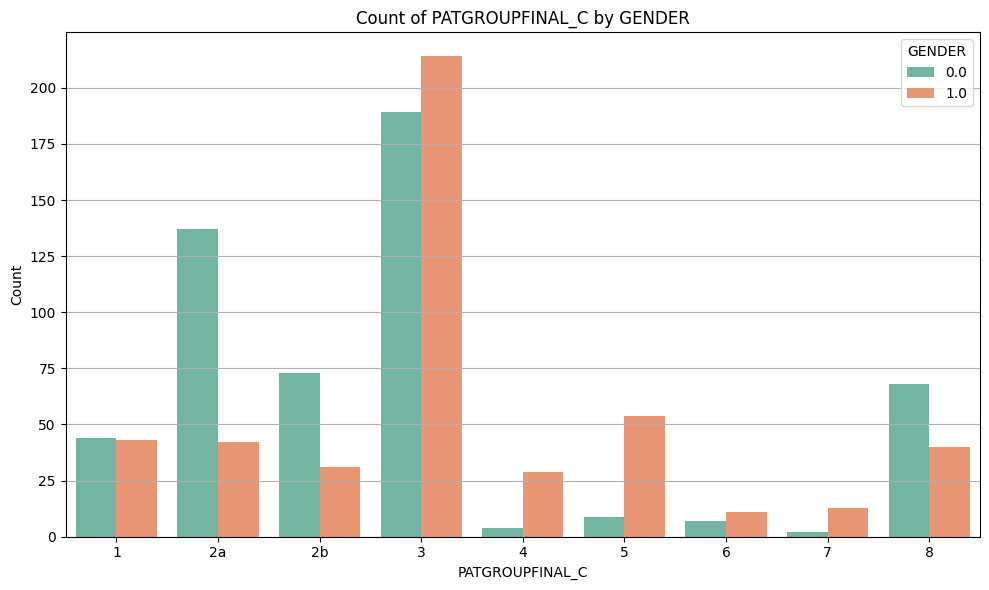

In [18]:
# color by gender
category_col = "GENDER"
df_filtered = metadata_sorted_disease_group_df[["PATGROUPFINAL_C", category_col]].dropna()
plt.figure(figsize=(10, 6))
sns.countplot(data=df_filtered, x=value_col, hue=category_col, palette='Set2')

plt.title(f'Count of {value_col} by {category_col}')
plt.xlabel(value_col)
plt.ylabel('Count')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [19]:
print("Value counts for column:", category_col)
print(metadata_df[category_col].value_counts())

Value counts for column: GENDER
GENDER
0.0    533
1.0    477
Name: count, dtype: int64


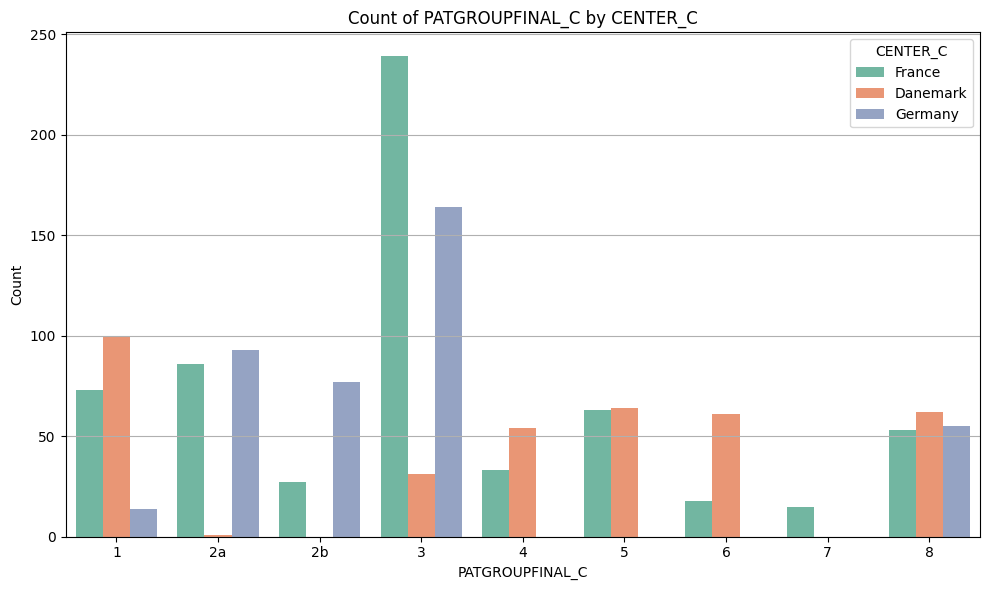

In [20]:
# color by country
category_col = "CENTER_C"
df_filtered = metadata_sorted_disease_group_df[["PATGROUPFINAL_C", category_col]].dropna()
plt.figure(figsize=(10, 6))
sns.countplot(data=df_filtered, x=value_col, hue=category_col, palette='Set2')

plt.title(f'Count of {value_col} by {category_col}')
plt.xlabel(value_col)
plt.ylabel('Count')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [21]:
print("Value counts for column:", category_col)
print(metadata_df[category_col].value_counts())

Value counts for column: CENTER_C
CENTER_C
France      607
Germany     403
Danemark    373
Name: count, dtype: int64


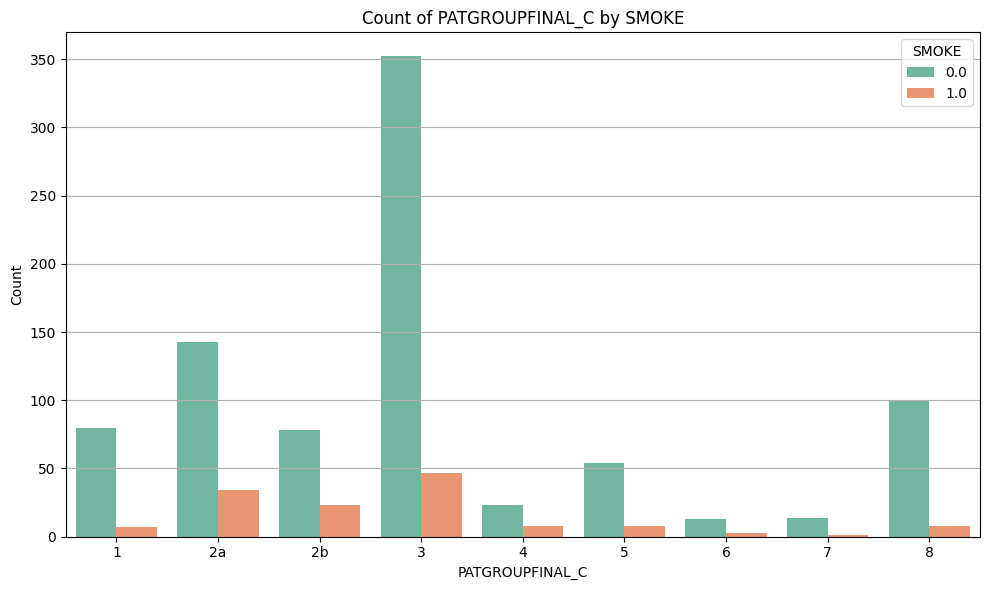

In [22]:
# color by smoking status
category_col = "SMOKE"
df_filtered = metadata_sorted_disease_group_df[["PATGROUPFINAL_C", category_col]].dropna()
plt.figure(figsize=(10, 6))
sns.countplot(data=df_filtered, x=value_col, hue=category_col, palette='Set2')

plt.title(f'Count of {value_col} by {category_col}')
plt.xlabel(value_col)
plt.ylabel('Count')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [23]:
print("Value counts for column:", category_col)
print(metadata_df[category_col].value_counts())

Value counts for column: SMOKE
SMOKE
0.0    857
1.0    139
Name: count, dtype: int64


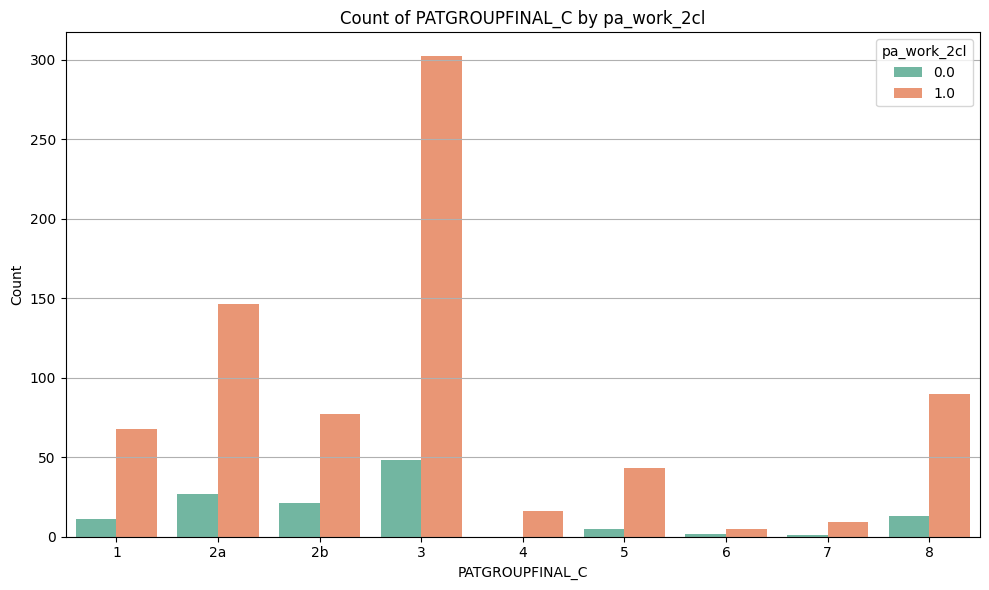

In [24]:
# color by workout status
category_col = "pa_work_2cl"
df_filtered = metadata_sorted_disease_group_df[["PATGROUPFINAL_C", category_col]].dropna()
plt.figure(figsize=(10, 6))
sns.countplot(data=df_filtered, x=value_col, hue=category_col, palette='Set2')

plt.title(f'Count of {value_col} by {category_col}')
plt.xlabel(value_col)
plt.ylabel('Count')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [25]:
print("Value counts for column:", category_col)
print(metadata_df[category_col].value_counts())

Value counts for column: pa_work_2cl
pa_work_2cl
1.0    756
0.0    128
Name: count, dtype: int64


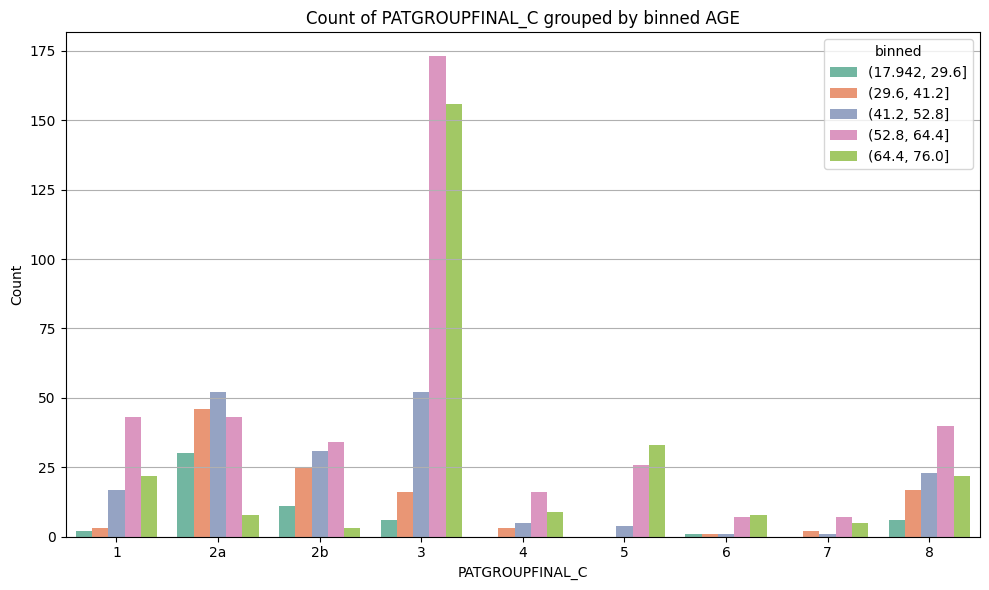

In [26]:
# color by age group
category_col = "AGE"
df_filtered = metadata_sorted_disease_group_df[[value_col, category_col]].dropna()

num_bins = 5
binned = pd.cut(df_filtered[category_col], bins=num_bins)

# Use the interval labels directly to preserve order
df_filtered['binned'] = binned

# Plot with hue ordered as intervals
plt.figure(figsize=(10, 6))
sns.countplot(data=df_filtered, x=value_col, hue='binned', 
              palette='Set2', hue_order=sorted(df_filtered['binned'].unique()))

plt.title(f'Count of {value_col} grouped by binned {category_col}')
plt.xlabel(value_col)
plt.ylabel('Count')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [27]:
print("Value counts for column:binned")
print(df_filtered['binned'].value_counts())

Value counts for column:binned
binned
(52.8, 64.4]      389
(64.4, 76.0]      266
(41.2, 52.8]      186
(29.6, 41.2]      113
(17.942, 29.6]     56
Name: count, dtype: int64


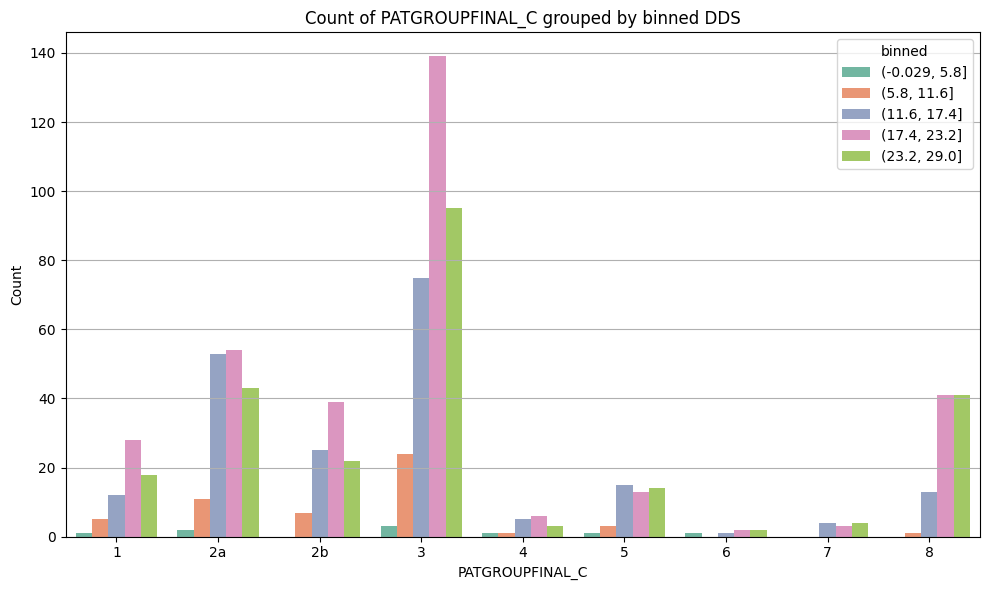

In [28]:
# color by DDS
category_col = "DDS"
df_filtered = metadata_sorted_disease_group_df[[value_col, category_col]].dropna()

num_bins = 5
binned = pd.cut(df_filtered[category_col], bins=num_bins)

# Use the interval labels directly to preserve order
df_filtered['binned'] = binned

# Plot with hue ordered as intervals
plt.figure(figsize=(10, 6))
sns.countplot(data=df_filtered, x=value_col, hue='binned', 
              palette='Set2', hue_order=sorted(df_filtered['binned'].unique()))

plt.title(f'Count of {value_col} grouped by binned {category_col}')
plt.xlabel(value_col)
plt.ylabel('Count')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [29]:
print("Value counts for column:binned")
print(df_filtered['binned'].value_counts())

Value counts for column:binned
binned
(17.4, 23.2]     325
(23.2, 29.0]     242
(11.6, 17.4]     203
(5.8, 11.6]       52
(-0.029, 5.8]      9
Name: count, dtype: int64


In [30]:
for col in metadata_sorted_disease_group_df.columns:
    print(f"Column: {col} has nulls: {metadata_sorted_disease_group_df[col].isnull().any()}")

Column: SampleID has nulls: False
Column: PATGROUPFINAL_C has nulls: False
Column: GENDER has nulls: True
Column: AGE has nulls: True
Column: CENTER_C has nulls: False
Column: SMOKE has nulls: True
Column: pa_work_2cl has nulls: True
Column: DDS has nulls: True


In [31]:
for col in metagenomics_df.columns:
    print(f"Column: {col} has nulls: {metagenomics_df[col].isnull().any()}")

Column: SampleID has nulls: False
Column: CAG-83 sp900552725 has nulls: False
Column: CAG-83 sp001916855 has nulls: False
Column: CAG-83 sp900547745 has nulls: False
Column: CAG-83 sp000435975 has nulls: False
Column: CAG-83 sp900545585 has nulls: False
Column: CAG-83 sp900548615 has nulls: False
Column: CAG-83 sp000431575 has nulls: False
Column: CAG-83 sp900757415 has nulls: False
Column: CAG-83 sp900549395 has nulls: False
Column: CAG-83 sp900545495 has nulls: False
Column: CAG-83 sp003539495 has nulls: False
Column: CAG-83 sp900556015 has nulls: False
Column: CAG-83 sp900554275 has nulls: False
Column: CAG-83 sp900551995 has nulls: False
Column: CAG-83 sp003487665 has nulls: False
Column: CAG-83 sp002438575 has nulls: False
Column: CAG-83 sp900552475 has nulls: False
Column: CAG-83 sp000435555 has nulls: False
Column: CAG-170 sp000432135 has nulls: False
Column: CAG-170 sp002404795 has nulls: False
Column: CAG-170 sp900545925 has nulls: False
Column: CAG-170 sp900549635 has nulls: 

### Part 2 - Microbiome composition

In [32]:
def shannon_diversity(row):
    proportions = row.values
    # Filter out zeros to avoid log(0)
    proportions = proportions[proportions > 0]
    return -np.sum(proportions * np.log(proportions))

In [33]:
# split the df into subjects and controls
subjects_sample_ids = metadata_df[metadata_df["PATGROUPFINAL_C"] != "8"]["SampleID"]
controls_sample_ids = metadata_df[metadata_df["PATGROUPFINAL_C"] == "8"]["SampleID"]
print(len(subjects_sample_ids), len(controls_sample_ids))
microbiome_counts_df = pd.read_csv("train/microbiome.csv").set_index("SampleID")

# convert to relative abundance
microbiome_df = microbiome_counts_df.div(microbiome_counts_df.sum(axis=1), axis=0)


microbiome_df["alpha_div"] = microbiome_df.apply(shannon_diversity, axis=1)
microbiome_df.head()

1213 170


,CAG-83 sp900552725,CAG-83 sp001916855,CAG-83 sp900547745,CAG-83 sp000435975,CAG-83 sp900545585,CAG-83 sp900548615,CAG-83 sp000431575,CAG-83 sp900757415,CAG-83 sp900549395,CAG-83 sp900545495,...,Phascolarctobacterium_A succinatutens_A,Dialister sp000434475,Megasphaera elsdenii,Prevotella sp002297965,Prevotella sp900556395,Prevotella sp900557035,Dialister sp002320515,Allisonella histaminiformans,Cryptobacteroides sp000434935,alpha_div
SampleID,,,,,,,,,,,,,,,,,,,,,
x30MCx2308,0.000222,0.002017,0.000147,0.010827,0.000111,0.004176,0.001042,0.000570,0.000385,0.000241,...,0.003317,0.000008,5.709643e-06,5.566902e-05,0.006868,0.000190,0.000001,1.319562e-04,0.003551,4.707651
x30MCx3215,0.000156,0.003506,0.000114,0.000412,0.002269,0.000152,0.002990,0.000431,0.000408,0.000185,...,0.000003,0.000009,6.270430e-07,9.405645e-07,0.000001,0.000000,0.008000,7.524516e-07,0.000000,4.631882
x30MCx2753,0.000000,0.000015,0.000000,0.000000,0.000000,0.000007,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,3.663082e-06,0.000000,0.000002,0.000002,0.000000e+00,0.000000,3.001607
x12MCx2285,0.001745,0.001852,0.001297,0.000323,0.001399,0.005169,0.000634,0.000587,0.000859,0.000609,...,0.002613,0.000000,7.667478e-06,1.323881e-06,0.000009,0.000012,0.000001,5.516171e-07,0.006388,4.624050
x30MCx1686,0.000069,0.000484,0.000052,0.000225,0.000023,0.000109,0.005628,0.000306,0.000163,0.000095,...,0.000002,0.000000,0.000000e+00,1.006932e-06,0.000003,0.000000,0.000000,0.000000e+00,0.000002,4.611614


In [34]:
subjects_microbiome_df = microbiome_df.loc[subjects_sample_ids]
controls_microbiome_df = microbiome_df.loc[controls_sample_ids]

In [35]:
subjects_microbiome_df.describe()["alpha_div"], controls_microbiome_df.describe()["alpha_div"]

(count    1213.000000
 mean        4.238754
 std         0.495951
 min         2.097243
 25%         3.929336
 50%         4.319333
 75%         4.620368
 max         5.222583
 Name: alpha_div, dtype: float64,
 count    170.000000
 mean       4.509892
 std        0.351663
 min        3.105718
 25%        4.306736
 50%        4.560850
 75%        4.761157
 max        5.140108
 Name: alpha_div, dtype: float64)

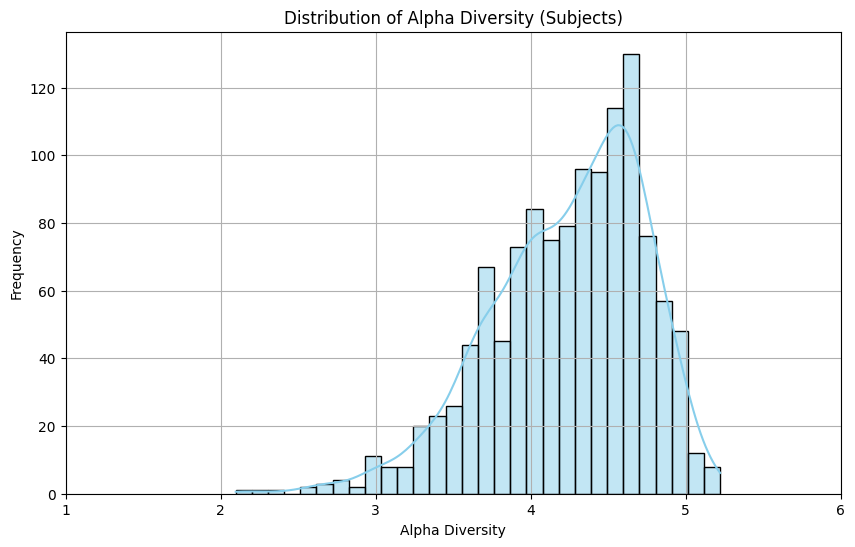

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(subjects_microbiome_df["alpha_div"], kde=True, bins=30, color='skyblue')
plt.title(f'Distribution of Alpha Diversity (Subjects)')
plt.xlabel("Alpha Diversity")
plt.ylabel('Frequency')
plt.grid(True)
plt.xlim(1, 6)
plt.show()

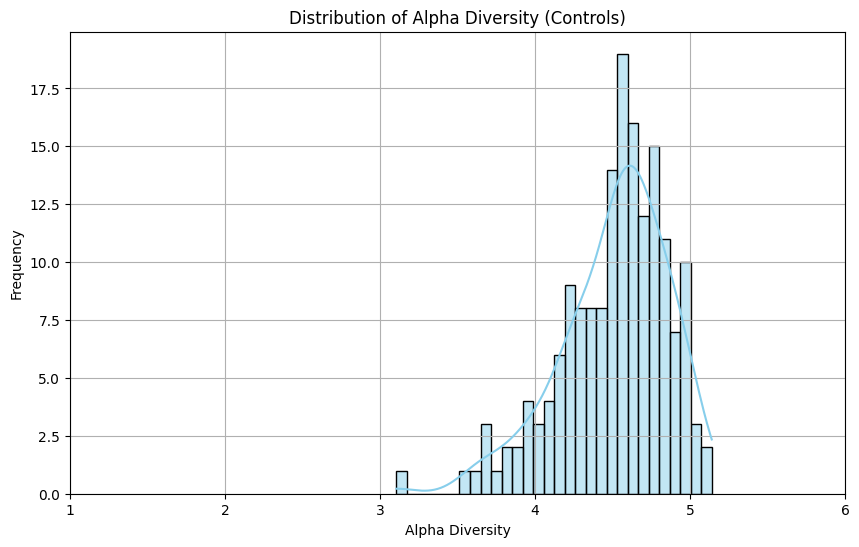

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(controls_microbiome_df["alpha_div"], kde=True, bins=30, color='skyblue')
plt.title(f'Distribution of Alpha Diversity (Controls)')
plt.xlabel("Alpha Diversity")
plt.ylabel('Frequency')
plt.grid(True)
plt.xlim(1, 6)

plt.show()

In [38]:
from scipy.spatial.distance import pdist, squareform

microbiome_df_no_alpha_div = microbiome_df.drop("alpha_div", axis=1)

dist_array = pdist(microbiome_df_no_alpha_div.values, metric='braycurtis')
dist_matrix = squareform(dist_array)

# Put into DataFrame
braycurtis_df = pd.DataFrame(dist_matrix, 
                             index=microbiome_df_no_alpha_div.index, 
                             columns=microbiome_df_no_alpha_div.index)

#### Pinting PCA

d:\uni\microbiome project\take2\venv\Lib\site-packages\skbio\stats\ordination\_principal_coordinate_analysis.py:258: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.9688917628719871 whereas the largest positive one is 66.29522962759545.
  warn(
C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\1508123927.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\1508123927.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame b

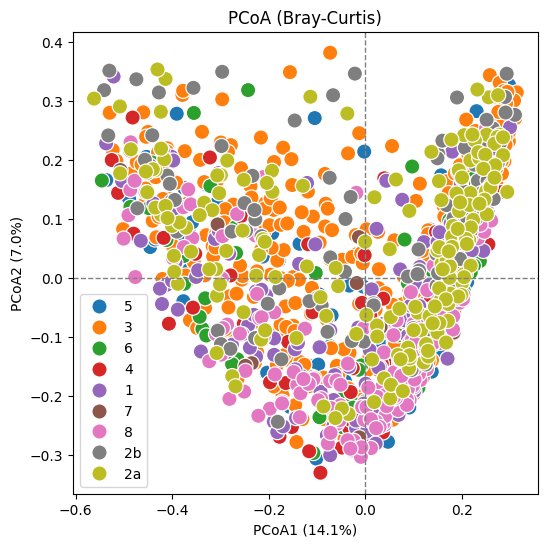

In [39]:
from skbio.stats.ordination import pcoa


pcoa_results = pcoa(braycurtis_df)

coords = pcoa_results.samples.iloc[:, :2]
coords.index = braycurtis_df.index 
coords = coords.join(metadata_df.set_index("SampleID"), on="SampleID")  # merge metadata for plotting

# Plot with seaborn
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=coords,
    x=coords.columns[0],
    y=coords.columns[1],
    hue="PATGROUPFINAL_C",   # color by label
    s=120
)

plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")
plt.title("PCoA (Bray-Curtis)")
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(0, color="gray", lw=1, ls="--")
plt.legend()
plt.show()

C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\3949775721.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\3949775721.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")


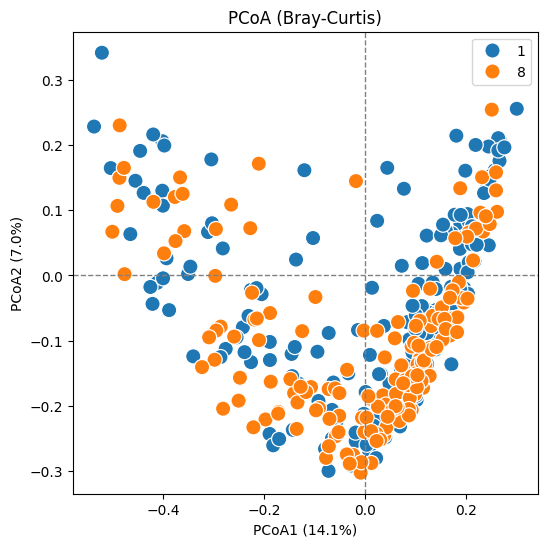

In [40]:
# Plot with seaborn
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=coords[coords["PATGROUPFINAL_C"].isin(["1", "8"])],
    x=coords.columns[0],
    y=coords.columns[1],
    hue="PATGROUPFINAL_C",   # color by label
    s=120
)

plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")
plt.title("PCoA (Bray-Curtis)")
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(0, color="gray", lw=1, ls="--")
plt.legend()
plt.show()

C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\3324891992.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\3324891992.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")


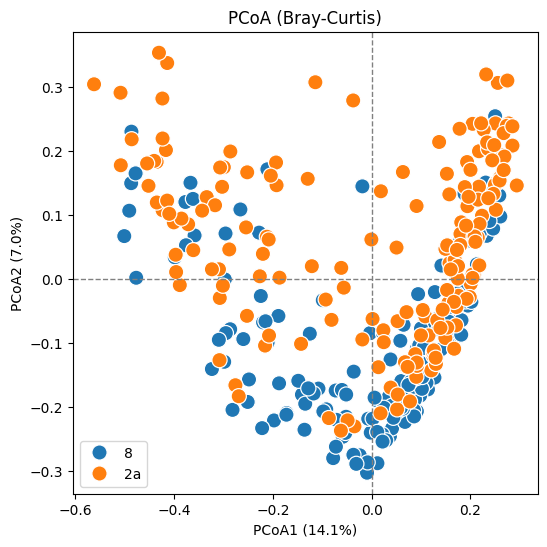

In [41]:
# Plot with seaborn
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=coords[coords["PATGROUPFINAL_C"].isin(["2a", "8"])],
    x=coords.columns[0],
    y=coords.columns[1],
    hue="PATGROUPFINAL_C",   # color by label
    s=120
)

plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")
plt.title("PCoA (Bray-Curtis)")
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(0, color="gray", lw=1, ls="--")
plt.legend()
plt.show()

C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\3528784651.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\3528784651.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")


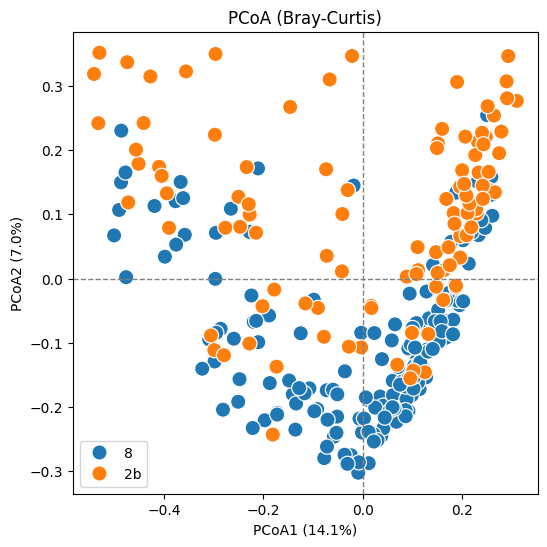

In [42]:
# Plot with seaborn
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=coords[coords["PATGROUPFINAL_C"].isin(["2b", "8"])],
    x=coords.columns[0],
    y=coords.columns[1],
    hue="PATGROUPFINAL_C",   # color by label
    s=120
)

plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")
plt.title("PCoA (Bray-Curtis)")
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(0, color="gray", lw=1, ls="--")
plt.legend()
plt.show()

C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\693898523.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\693898523.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")


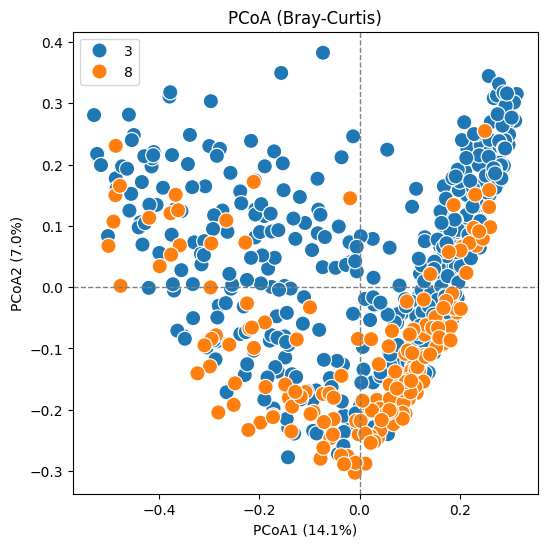

In [43]:
# Plot with seaborn
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=coords[coords["PATGROUPFINAL_C"].isin(["3", "8"])],
    x=coords.columns[0],
    y=coords.columns[1],
    hue="PATGROUPFINAL_C",   # color by label
    s=120
)

plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")
plt.title("PCoA (Bray-Curtis)")
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(0, color="gray", lw=1, ls="--")
plt.legend()
plt.show()

C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\3808310013.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\3808310013.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")


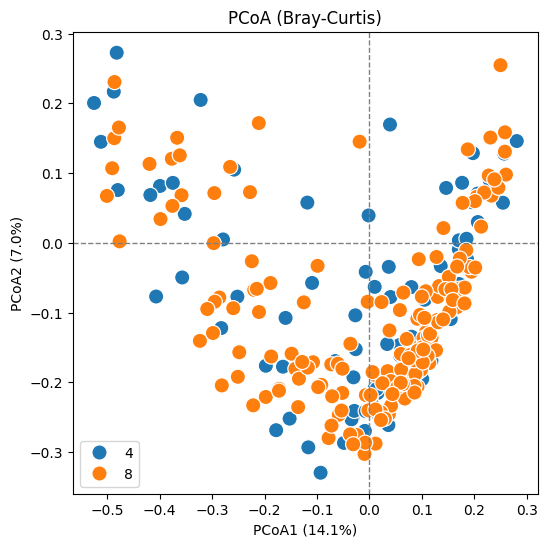

In [44]:
# Plot with seaborn
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=coords[coords["PATGROUPFINAL_C"].isin(["4", "8"])],
    x=coords.columns[0],
    y=coords.columns[1],
    hue="PATGROUPFINAL_C",   # color by label
    s=120
)

plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")
plt.title("PCoA (Bray-Curtis)")
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(0, color="gray", lw=1, ls="--")
plt.legend()
plt.show()

C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\1945746878.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\1945746878.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")


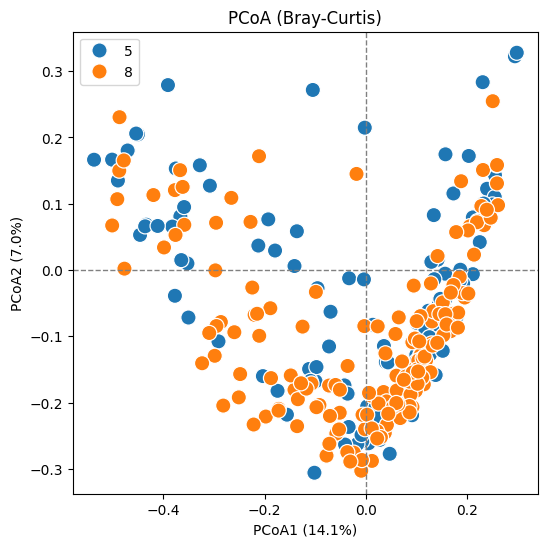

In [45]:
# Plot with seaborn
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=coords[coords["PATGROUPFINAL_C"].isin(["5", "8"])],
    x=coords.columns[0],
    y=coords.columns[1],
    hue="PATGROUPFINAL_C",   # color by label
    s=120
)

plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")
plt.title("PCoA (Bray-Curtis)")
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(0, color="gray", lw=1, ls="--")
plt.legend()
plt.show()

C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\1389060210.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\1389060210.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")


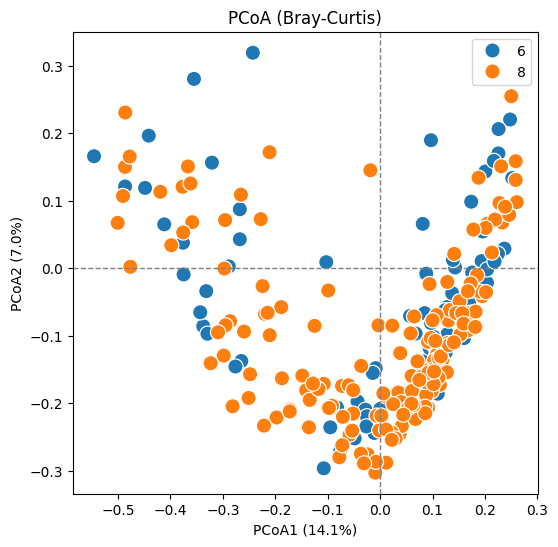

In [46]:
# Plot with seaborn
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=coords[coords["PATGROUPFINAL_C"].isin(["6", "8"])],
    x=coords.columns[0],
    y=coords.columns[1],
    hue="PATGROUPFINAL_C",   # color by label
    s=120
)

plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")
plt.title("PCoA (Bray-Curtis)")
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(0, color="gray", lw=1, ls="--")
plt.legend()
plt.show()

C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\1365343071.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\1365343071.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")


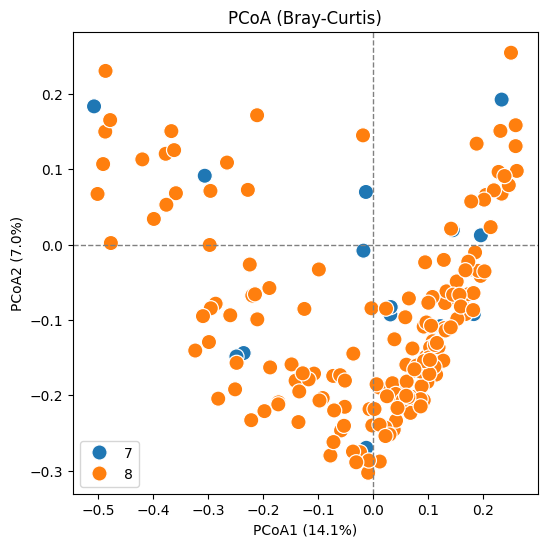

In [47]:
# Plot with seaborn
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=coords[coords["PATGROUPFINAL_C"].isin(["7", "8"])],
    x=coords.columns[0],
    y=coords.columns[1],
    hue="PATGROUPFINAL_C",   # color by label
    s=120
)

plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")
plt.title("PCoA (Bray-Curtis)")
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(0, color="gray", lw=1, ls="--")
plt.legend()
plt.show()

C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\1536733666.py:15: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Win10 User\AppData\Local\Temp\ipykernel_16080\1536733666.py:16: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



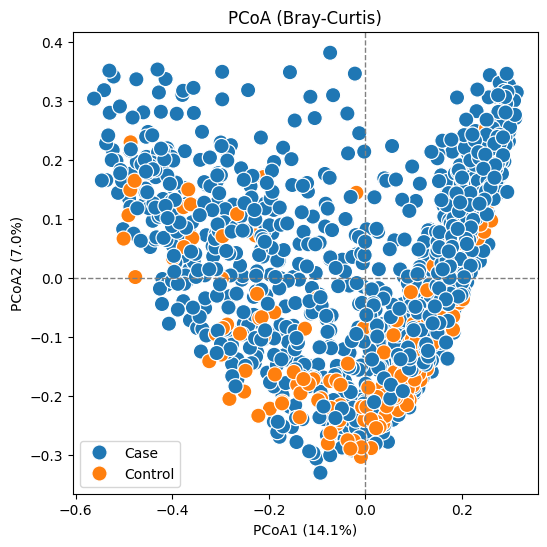

In [74]:
coords["is_control"] = coords["PATGROUPFINAL_C"] == "8"
coords["is_control"] = coords["is_control"].map({True: "Control", False: "Case"})


# Plot with seaborn
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=coords,
    x=coords.columns[0],
    y=coords.columns[1],
    hue="is_control",   # color by label
    s=120
)

plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained[0]*100:.1f}%)")
plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained[1]*100:.1f}%)")
plt.title("PCoA (Bray-Curtis)")
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(0, color="gray", lw=1, ls="--")
plt.legend()
plt.show()

#### Other suff

In [49]:
for group_a in metadata_df["PATGROUPFINAL_C"].unique():
    for group_b in metadata_df["PATGROUPFINAL_C"].unique():
        if group_a != group_b:
            group_a_samples = metadata_df[metadata_df["PATGROUPFINAL_C"] == group_a]["SampleID"]
            group_b_samples = metadata_df[metadata_df["PATGROUPFINAL_C"] == group_b]["SampleID"]
            # Calculate the distance between the two groups
            dist = braycurtis_df.loc[group_a_samples, group_b_samples].values.flatten()
            print(f"Mean Bray-Curtis distance between {group_a} and {group_b}: {dist.mean():.4f}")

Mean Bray-Curtis distance between 5 and 3: 0.7264
Mean Bray-Curtis distance between 5 and 6: 0.7187
Mean Bray-Curtis distance between 5 and 4: 0.7097
Mean Bray-Curtis distance between 5 and 1: 0.7050
Mean Bray-Curtis distance between 5 and 7: 0.7055
Mean Bray-Curtis distance between 5 and 8: 0.7017
Mean Bray-Curtis distance between 5 and 2b: 0.7449
Mean Bray-Curtis distance between 5 and 2a: 0.7277
Mean Bray-Curtis distance between 3 and 5: 0.7264
Mean Bray-Curtis distance between 3 and 6: 0.7371
Mean Bray-Curtis distance between 3 and 4: 0.7346
Mean Bray-Curtis distance between 3 and 1: 0.7248
Mean Bray-Curtis distance between 3 and 7: 0.7244
Mean Bray-Curtis distance between 3 and 8: 0.7295
Mean Bray-Curtis distance between 3 and 2b: 0.7413
Mean Bray-Curtis distance between 3 and 2a: 0.7325
Mean Bray-Curtis distance between 6 and 5: 0.7187
Mean Bray-Curtis distance between 6 and 3: 0.7371
Mean Bray-Curtis distance between 6 and 4: 0.7204
Mean Bray-Curtis distance between 6 and 1: 0.7

In [77]:
control_samples = metadata_df[metadata_df["PATGROUPFINAL_C"] == "8"]["SampleID"]
for group in metadata_df["PATGROUPFINAL_C"].unique():
    for bacteria in microbiome_df.columns[1:]:
        group_samples = metadata_df[metadata_df["PATGROUPFINAL_C"] == group]["SampleID"]
        mean_abundance = microbiome_df.loc[group_samples][bacteria].mean()
        mean_abundance_control = microbiome_df.loc[control_samples][bacteria].mean()
        if mean_abundance_control > 10*mean_abundance or mean_abundance_control < 0.01*mean_abundance:
            print(f"{bacteria} in {group} is significantly different from control: {mean_abundance:.4f} vs {mean_abundance_control:.4f}")

Sodaliphilus sp004557565 in 5 is significantly different from control: 0.0001 vs 0.0013
CAG-882 sp003486385 in 3 is significantly different from control: 0.0001 vs 0.0018
CAG-475 sp000434435 in 3 is significantly different from control: 0.0003 vs 0.0033
CAG-533 sp000434495 in 3 is significantly different from control: 0.0001 vs 0.0013
CAG-628 sp003524085 in 3 is significantly different from control: 0.0000 vs 0.0005
CAG-288 sp000437395 in 3 is significantly different from control: 0.0001 vs 0.0011
CAG-307 sp001916215 in 3 is significantly different from control: 0.0002 vs 0.0023
CAG-345 sp000433315 in 3 is significantly different from control: 0.0000 vs 0.0015
Prevotella sp002300055 in 4 is significantly different from control: 0.0001 vs 0.0022
Limivicinus sp900547315 in 7 is significantly different from control: 0.0001 vs 0.0015
Limivicinus sp900549645 in 7 is significantly different from control: 0.0000 vs 0.0002
Negativibacillus faecipullorum in 7 is significantly different from con

### Part 3 - Adding metabolites

In [51]:
metabolomics_counts_df = pd.read_csv("train/serum_lipo.csv").set_index("SampleID")

In [52]:
# The metabolomics data also needs to be converted to display relative abundance
# Since the exact values may vary widely from sample to sample

metabolomics_df = metabolomics_counts_df.div(metabolomics_counts_df.sum(axis=1), axis=0)

metabolomics_df.head(1)

,H1A1,H1A2,H1CH,H1FC,H1PL,H1TG,H2A1,H2A2,H2CH,H2FC,...,V5TG,V6CH,V6FC,V6PL,V6TG,VLAB,VLCH,VLFC,VLPL,VLTG
SampleID,,,,,,,,,,,,,,,,,,,,,
x30MCx2308,0.034415,0.003811,0.019222,0.005142,0.025599,0.003394,0.014769,0.00267,0.006387,0.001835,...,0.001546,0.00008,0.00005,0.000131,0.0014,0.001896,0.005362,0.002567,0.005439,0.01789


In [82]:
control_samples = metadata_df[metadata_df["PATGROUPFINAL_C"] == "8"]["SampleID"]
    

for group in metadata_df["PATGROUPFINAL_C"].unique():
    group_samples = metadata_df[metadata_df["PATGROUPFINAL_C"] == group]["SampleID"]
    for metabolite in metabolomics_df.columns:
        mean_abundance = metabolomics_df.loc[group_samples][metabolite].mean()
        mean_abundance_control = metabolomics_df.loc[control_samples][metabolite].mean()
        if mean_abundance_control > 2*mean_abundance or mean_abundance_control < 0.5*mean_abundance:
            print(f"{metabolite} in {GROUP_ID_TO_NAME[group]} is significantly different from control: {mean_abundance:.4f} vs {mean_abundance_control:.4f}")

V1TG in Chronic CAD, no Heart Failure is significantly different from control: 0.0132 vs 0.0059
V1CH in T2D, no CAD is significantly different from control: 0.0032 vs 0.0015
V1FC in T2D, no CAD is significantly different from control: 0.0015 vs 0.0007
V1PL in T2D, no CAD is significantly different from control: 0.0032 vs 0.0012
V1TG in T2D, no CAD is significantly different from control: 0.0188 vs 0.0059
V2CH in T2D, no CAD is significantly different from control: 0.0012 vs 0.0006
V2FC in T2D, no CAD is significantly different from control: 0.0006 vs 0.0002
V1PL in Chronic CAD, Heart Failure is significantly different from control: 0.0025 vs 0.0012
V1TG in Chronic CAD, Heart Failure is significantly different from control: 0.0141 vs 0.0059
L3CH in Acute CAD is significantly different from control: 0.0046 vs 0.0098
V1FC in Acute CAD is significantly different from control: 0.0014 vs 0.0007
V1PL in Acute CAD is significantly different from control: 0.0027 vs 0.0012
V1TG in Acute CAD is s

In [54]:
microbiome_aligned, metabolomics_aligned = microbiome_df.align(metabolomics_df, join='inner', axis=0)

# Create empty matrix to fill
corr_matrix = pd.DataFrame(index=microbiome_aligned.columns, 
                           columns=metabolomics_aligned.columns)

# Compute correlations
for col1 in microbiome_aligned.columns:
    for col2 in metabolomics_aligned.columns:
        corr_matrix.loc[col1, col2] = microbiome_aligned[col1].corr(metabolomics_aligned[col2])

corr_matrix = corr_matrix.astype(float)  # ensure float type

In [55]:
corr_matrix.shape

(665, 105)

In [56]:
fig = px.imshow(corr_matrix,
                color_continuous_scale="RdBu",
                zmin=-1, zmax=1)
fig.update_layout(height=700, width=1200)
fig.show()

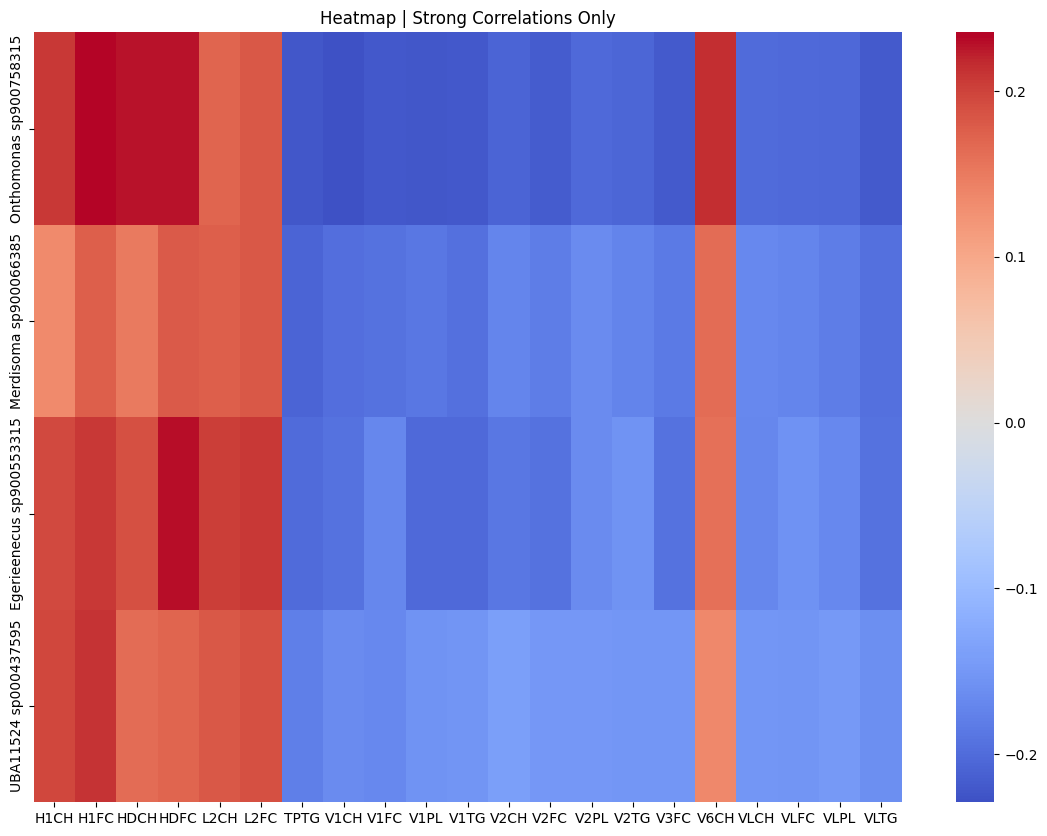

In [57]:
filtered = corr_matrix.loc[
    (corr_matrix.abs() >= 0.2).any(axis=1),
    (corr_matrix.abs() >= 0.2).any(axis=0)
]

plt.figure(figsize=(14, 10))
sns.heatmap(filtered, cmap="coolwarm", center=0)
plt.title("Heatmap | Strong Correlations Only")
plt.show()

#### Confounding factors affecting metabolites

In [58]:
def pp_means(means):

    sorted_items = sorted(means.items(), key=lambda x: x[0])
    res = "{:<20} {}".format("KEY", "VALUE")
    res += "\n" + "-" * 40 + "\n"

    for k, v in sorted_items:
        res += "{:<20} {}".format(str(k), str(v)) + "\n"
    return res

In [83]:
for metabolite in metabolomics_df.columns:
    means = {}
    for group in metadata_df["GENDER"].unique():
        if np.isnan(group):
            continue
        group_samples = metadata_df[metadata_df["GENDER"] == group]["SampleID"]
        mean_abundance = metabolomics_df.loc[group_samples][metabolite].mean()
        means[group] = mean_abundance
    
    max_abundance = max(means.values())
    min_abundance = min(means.values())
    if max_abundance > 1.3 * min_abundance:
        print(f"{metabolite} shows variation across GENDER groups:\n{pp_means(means)}")

V1PL shows variation across GENDER groups:
KEY                  VALUE
----------------------------------------
0.0                  0.002419812675050383
1.0                  0.003216140668375628

V1TG shows variation across GENDER groups:
KEY                  VALUE
----------------------------------------
0.0                  0.013557382145176622
1.0                  0.018407982220500208



In [60]:
for metabolite in metabolomics_df.columns:
    means = {}
    for group in metadata_df["SMOKE"].unique():
        if np.isnan(group):
            continue
        group_samples = metadata_df[metadata_df["SMOKE"] == group]["SampleID"]
        mean_abundance = metabolomics_df.loc[group_samples][metabolite].mean()
        means[group] = mean_abundance
    
    max_abundance = max(means.values())
    min_abundance = min(means.values())
    if max_abundance > 1.2 * min_abundance:
        print(f"{metabolite} shows variation across SMOKE groups:\n{pp_means(means)}")

IDTG shows variation across SMOKE groups:
KEY                  VALUE
----------------------------------------
0.0                  0.007590598475338368
1.0                  0.009139592144833605

V1TG shows variation across SMOKE groups:
KEY                  VALUE
----------------------------------------
0.0                  0.015434875738720877
1.0                  0.018630464498055638

V2FC shows variation across SMOKE groups:
KEY                  VALUE
----------------------------------------
0.0                  0.0004738967915190553
1.0                  0.0005728759717924673



In [61]:
for metabolite in metabolomics_df.columns:
    means = {}
    for group in metadata_df["CENTER_C"].unique():
        if type(group) == float and np.isnan(group):
            continue
        group_samples = metadata_df[metadata_df["CENTER_C"] == group]["SampleID"]
        mean_abundance = metabolomics_df.loc[group_samples][metabolite].mean()
        means[group] = mean_abundance
    
    max_abundance = max(means.values())
    min_abundance = min(means.values())
    if max_abundance > 1.2 * min_abundance:
        print(f"{metabolite} shows variation across CENTER_C groups:\n{pp_means(means)}")

H1A1 shows variation across CENTER_C groups:
KEY                  VALUE
----------------------------------------
Danemark             0.010762838023576549
France               0.008379691544772055
Germany              0.008601993348069614

H1A2 shows variation across CENTER_C groups:
KEY                  VALUE
----------------------------------------
Danemark             0.001296180356481759
France               0.000984989996198002
Germany              0.0011028765366923815

H1CH shows variation across CENTER_C groups:
KEY                  VALUE
----------------------------------------
Danemark             0.007191464237960554
France               0.005479229221451801
Germany              0.005642484116715299

H1FC shows variation across CENTER_C groups:
KEY                  VALUE
----------------------------------------
Danemark             0.002432441445379731
France               0.0019113783446174572
Germany              0.0019224850899380965

H1PL shows variation across CENTER_C 

In [62]:
for metabolite in metabolomics_df.columns:
    means = {}
    for group in metadata_df.dropna()["pa_work_2cl"].unique():
        group_samples = metadata_df[metadata_df["pa_work_2cl"] == group]["SampleID"]
        mean_abundance = metabolomics_df.loc[group_samples][metabolite].mean()
        means[group] = mean_abundance
    
    max_abundance = max(means.values())
    min_abundance = min(means.values())
    if max_abundance > 1.1 * min_abundance:
        print(f"{metabolite} shows variation across pa_work_2cl groups:\n{pp_means(means)}")

V6TG shows variation across pa_work_2cl groups:
KEY                  VALUE
----------------------------------------
0.0                  0.001023221533987982
1.0                  0.0009256787395016715



In [63]:
num_bins = 5
binned = pd.cut(metadata_df["AGE"], bins=num_bins)

# Use the interval labels directly to preserve order
metadata_df['AGE_binned'] = binned

for metabolite in metabolomics_df.columns:
    means = {}
    for group in metadata_df.dropna()["AGE_binned"].unique():
        group_samples = metadata_df[metadata_df["AGE_binned"] == group]["SampleID"]
        mean_abundance = metabolomics_df.loc[group_samples][metabolite].mean()
        means[group] = mean_abundance
    
    max_abundance = max(means.values())
    min_abundance = min(means.values())
    if max_abundance > 1.2 * min_abundance:
        print(f"{metabolite} shows variation across AGE groups:\n{pp_means(means)}")

L2CH shows variation across AGE groups:
KEY                  VALUE
----------------------------------------
(17.942, 29.6]       0.006722329280854359
(29.6, 41.2]         0.007125620699067743
(41.2, 52.8]         0.0063503441464088225
(52.8, 64.4]         0.0062382877941943365
(64.4, 76.0]         0.00589791013243745

V2CH shows variation across AGE groups:
KEY                  VALUE
----------------------------------------
(17.942, 29.6]       0.0010073065562693714
(29.6, 41.2]         0.0009594048833240879
(41.2, 52.8]         0.0011590706965866782
(52.8, 64.4]         0.0010912261859304263
(64.4, 76.0]         0.0011171633609519365

V2FC shows variation across AGE groups:
KEY                  VALUE
----------------------------------------
(17.942, 29.6]       0.00044949974528688853
(29.6, 41.2]         0.0004263095414471368
(41.2, 52.8]         0.0005183938749433386
(52.8, 64.4]         0.00048814562560381
(64.4, 76.0]         0.0004956747355411349

V5FC shows variation across AGE g

In [64]:
num_bins = 5
binned = pd.cut(metadata_df["DDS"], bins=num_bins)

# Use the interval labels directly to preserve order
metadata_df['DDS_binned'] = binned

for metabolite in metabolomics_df.columns:
    means = {}
    for group in metadata_df.dropna()["DDS_binned"].unique():
        group_samples = metadata_df[metadata_df["DDS_binned"] == group]["SampleID"]
        mean_abundance = metabolomics_df.loc[group_samples][metabolite].mean()
        means[group] = mean_abundance
    
    max_abundance = max(means.values())
    min_abundance = min(means.values())
    if max_abundance > 1.2 * min_abundance:
        print(f"{metabolite} shows variation across DDS groups:\n{pp_means(means)}")

H1A1 shows variation across DDS groups:
KEY                  VALUE
----------------------------------------
(-0.029, 5.8]        0.007973246444300263
(5.8, 11.6]          0.007110735069414157
(11.6, 17.4]         0.008129573190145914
(17.4, 23.2]         0.008644543175030286
(23.2, 29.0]         0.00868545395750415

H1A2 shows variation across DDS groups:
KEY                  VALUE
----------------------------------------
(-0.029, 5.8]        0.0009926026218861788
(5.8, 11.6]          0.0008693684265571711
(11.6, 17.4]         0.001024835515381133
(17.4, 23.2]         0.001053294373245785
(23.2, 29.0]         0.0010473373363304123

IDTG shows variation across DDS groups:
KEY                  VALUE
----------------------------------------
(-0.029, 5.8]        0.009473124029638081
(5.8, 11.6]          0.009773896804003954
(11.6, 17.4]         0.008378630901513216
(17.4, 23.2]         0.007593753741916065
(23.2, 29.0]         0.007219778953316011

L1AB shows variation across DDS groups:
K

#### Confounding factors affecting microbiome diversity

In [65]:
for group in metadata_df.dropna()["GENDER"].unique():
    group_samples = metadata_df[metadata_df["GENDER"] == group]["SampleID"]
    print(f"GROUP: {group}, mean alpha_div: {microbiome_df.loc[group_samples]['alpha_div'].mean():.4f}")

GROUP: 1.0, mean alpha_div: 4.2454
GROUP: 0.0, mean alpha_div: 4.1601


In [66]:
for group in metadata_df.dropna()["SMOKE"].unique():
    group_samples = metadata_df[metadata_df["SMOKE"] == group]["SampleID"]
    print(f"GROUP: {group}, mean alpha_div: {microbiome_df.loc[group_samples]['alpha_div'].mean():.4f}")

GROUP: 0.0, mean alpha_div: 4.2228
GROUP: 1.0, mean alpha_div: 4.0641


In [67]:
for group in metadata_df["CENTER_C"].unique():
    group_samples = metadata_df[metadata_df["CENTER_C"] == group]["SampleID"]
    print(f"GROUP: {group}, mean alpha_div: {microbiome_df.loc[group_samples]['alpha_div'].mean():.4f}")

GROUP: Danemark, mean alpha_div: 4.4663
GROUP: France, mean alpha_div: 4.2332
GROUP: Germany, mean alpha_div: 4.1509


In [68]:
for group in metadata_df.dropna()["pa_work_2cl"].unique():
    group_samples = metadata_df[metadata_df["pa_work_2cl"] == group]["SampleID"]
    print(f"GROUP: {group}, mean alpha_div: {microbiome_df.loc[group_samples]['alpha_div'].mean():.4f}")

GROUP: 0.0, mean alpha_div: 4.1204
GROUP: 1.0, mean alpha_div: 4.2027


In [69]:
for group in sorted(metadata_df.dropna()["AGE_binned"].unique()):
    group_samples = metadata_df[metadata_df["AGE_binned"] == group]["SampleID"]
    print(f"GROUP: {group}, mean alpha_div: {microbiome_df.loc[group_samples]['alpha_div'].mean():.4f}")

GROUP: (17.942, 29.6], mean alpha_div: 4.0071
GROUP: (29.6, 41.2], mean alpha_div: 4.0721
GROUP: (41.2, 52.8], mean alpha_div: 4.1774
GROUP: (52.8, 64.4], mean alpha_div: 4.1929
GROUP: (64.4, 76.0], mean alpha_div: 4.3225


In [70]:
for group in sorted(metadata_df.dropna()["DDS_binned"].unique()):
    group_samples = metadata_df[metadata_df["DDS_binned"] == group]["SampleID"]
    print(f"GROUP: {group}, mean alpha_div: {microbiome_df.loc[group_samples]['alpha_div'].mean():.4f}")

GROUP: (-0.029, 5.8], mean alpha_div: 4.2262
GROUP: (5.8, 11.6], mean alpha_div: 4.0531
GROUP: (11.6, 17.4], mean alpha_div: 4.1148
GROUP: (17.4, 23.2], mean alpha_div: 4.2062
GROUP: (23.2, 29.0], mean alpha_div: 4.2685
